In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# УТИЛИТЫ
# ─────────────────────────────────────────────

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def collect_images(root: Path) -> dict[str, list[Path]]:
    """Рекурсивно собирает изображения, группируя по родительской папке."""
    groups = defaultdict(list)
    for p in root.rglob('*'):
        if p.suffix.lower() in IMG_EXTS:
            groups[p.parent.name].append(p)
    return dict(groups)

def get_image_stats(paths: list[Path], sample: int = 200) -> pd.DataFrame:
    """Считает базовую статистику по выборке изображений."""
    records = []
    for p in paths[:sample]:
        img = cv2.imread(str(p))
        if img is None:
            continue
        h, w, c = img.shape
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        records.append({
            'file': p.name,
            'width': w,
            'height': h,
            'aspect': round(w / h, 2),
            'brightness': round(gray.mean(), 2),
            'contrast': round(gray.std(), 2),
            'blur': round(cv2.Laplacian(gray, cv2.CV_64F).var(), 2),
        })
    return pd.DataFrame(records)


# ─────────────────────────────────────────────
# ЧАСТЬ 1: ACDC
# ─────────────────────────────────────────────

BASE_DIR = Path('/Users/dmitrii/PycharmProjects/weather-classification/datasets')
acdc_root = BASE_DIR / 'ACDC'
dawn_root = BASE_DIR / 'DAWN'

print("=" * 50)
print("ACDC — структура датасета")
print("=" * 50)

# Ищем папки с условиями погоды
acdc_conditions = {}
# Стандартная структура: ACDC/rgb_anon/{condition}/{split}/
rgb_root = acdc_root / 'rgb_anon'
if not rgb_root.exists():
    rgb_root = acdc_root  # fallback: плоская структура

for condition_dir in sorted(rgb_root.iterdir()):
    if condition_dir.is_dir():
        imgs = list(condition_dir.rglob('*'))
        imgs = [p for p in imgs if p.suffix.lower() in IMG_EXTS]
        if imgs:
            acdc_conditions[condition_dir.name] = imgs

# Статистика по условиям
print(f"\n{'Условие':<15} {'Изображений':>12}")
print("-" * 30)
acdc_total = 0
for cond, imgs in acdc_conditions.items():
    print(f"{cond:<15} {len(imgs):>12}")
    acdc_total += len(imgs)
print(f"{'ИТОГО':<15} {acdc_total:>12}")

# DataFrame для ACDC
acdc_records = []
for cond, imgs in acdc_conditions.items():
    for p in imgs:
        # Определяем split из пути (train/val/test)
        parts = p.parts
        split = 'unknown'
        for part in parts:
            if part in ('train', 'val', 'test'):
                split = part
                break
        acdc_records.append({'condition': cond, 'split': split, 'path': str(p)})

acdc_df = pd.DataFrame(acdc_records)
print("\nРаспределение по splits:")
print(acdc_df.groupby(['condition', 'split']).size().unstack(fill_value=0).to_string())

# Статистика пикселей (сэмпл)
print("\nСчитаем статистику изображений ACDC (сэмпл 100 шт на условие)...")
acdc_stats_list = []
for cond, imgs in acdc_conditions.items():
    df_stats = get_image_stats(imgs, sample=100)
    df_stats['condition'] = cond
    acdc_stats_list.append(df_stats)

acdc_stats = pd.concat(acdc_stats_list, ignore_index=True)
print(acdc_stats.groupby('condition')[['brightness', 'contrast', 'blur', 'width', 'height']].mean().round(2))


# ─────────────────────────────────────────────
# ЧАСТЬ 2: DAWN
# ─────────────────────────────────────────────

print("\n" + "=" * 50)
print("DAWN — структура датасета")
print("=" * 50)

# DAWN структура: DAWN/{Fog,Rain,Sand,Snow}/  + xml-аннотации
dawn_conditions = {}
for cond_dir in sorted(dawn_root.iterdir()):
    if cond_dir.is_dir():
        imgs = [p for p in cond_dir.rglob('*') if p.suffix.lower() in IMG_EXTS]
        if imgs:
            dawn_conditions[cond_dir.name] = imgs

print(f"\n{'Условие':<15} {'Изображений':>12}")
print("-" * 30)
dawn_total = 0
for cond, imgs in dawn_conditions.items():
    print(f"{cond:<15} {len(imgs):>12}")
    dawn_total += len(imgs)
print(f"{'ИТОГО':<15} {dawn_total:>12}")

# Парсим XML-аннотации DAWN (Pascal VOC формат)
def parse_voc_xml(xml_path: Path) -> list[dict]:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    filename = root.findtext('filename', default=xml_path.stem)
    for obj in root.findall('object'):
        name = obj.findtext('name', default='unknown')
        bndbox = obj.find('bndbox')
        if bndbox is not None:
            xmin = float(bndbox.findtext('xmin', 0))
            ymin = float(bndbox.findtext('ymin', 0))
            xmax = float(bndbox.findtext('xmax', 0))
            ymax = float(bndbox.findtext('ymax', 0))
            objects.append({
                'filename': filename,
                'class': name,
                'xmin': xmin, 'ymin': ymin,
                'xmax': xmax, 'ymax': ymax,
                'bbox_w': xmax - xmin,
                'bbox_h': ymax - ymin,
                'bbox_area': (xmax - xmin) * (ymax - ymin),
            })
    return objects

dawn_annotations = []
for cond_dir in sorted(dawn_root.iterdir()):
    if cond_dir.is_dir():
        for xml_path in cond_dir.rglob('*.xml'):
            for ann in parse_voc_xml(xml_path):
                ann['condition'] = cond_dir.name
                dawn_annotations.append(ann)

dawn_ann_df = pd.DataFrame(dawn_annotations)

if not dawn_ann_df.empty:
    print("\nКлассы объектов в DAWN:")
    print(dawn_ann_df['class'].value_counts().to_string())
    print("\nОбъектов на условие погоды:")
    print(dawn_ann_df['condition'].value_counts().to_string())
    print("\nСредний размер bounding box (по условию):")
    print(dawn_ann_df.groupby('condition')[['bbox_w','bbox_h','bbox_area']].mean().round(1))
else:
    print("XML-аннотации не найдены — проверь структуру папки DAWN")

# Статистика пикселей DAWN
print("\nСчитаем статистику изображений DAWN (сэмпл 80 шт на условие)...")
dawn_stats_list = []
for cond, imgs in dawn_conditions.items():
    df_stats = get_image_stats(imgs, sample=80)
    df_stats['condition'] = cond
    dawn_stats_list.append(df_stats)

dawn_stats = pd.concat(dawn_stats_list, ignore_index=True)
print(dawn_stats.groupby('condition')[['brightness', 'contrast', 'blur']].mean().round(2))


# ─────────────────────────────────────────────
# ЧАСТЬ 3: ВИЗУАЛИЗАЦИИ
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA: ACDC & DAWN Weather Datasets', fontsize=16, fontweight='bold')
palette = {'fog': '#7FB3D3', 'night': '#2C3E50', 'rain': '#85C1E9',
           'snow': '#D5DBDB', 'sand': '#F0B27A', 'Sand': '#F0B27A',
           'Fog': '#7FB3D3', 'Rain': '#85C1E9', 'Snow': '#D5DBDB'}

# 1. ACDC — распределение по условиям
ax = axes[0, 0]
acdc_counts = {k: len(v) for k, v in acdc_conditions.items()}
colors = [palette.get(k, '#AED6F1') for k in acdc_counts]
ax.bar(acdc_counts.keys(), acdc_counts.values(), color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('ACDC: Изображений по условию')
ax.set_ylabel('Количество')
for bar, val in zip(ax.patches, acdc_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=10)

# 2. ACDC — яркость по условиям (boxplot)
ax = axes[0, 1]
conditions_order = list(acdc_conditions.keys())
data_brightness = [acdc_stats[acdc_stats['condition'] == c]['brightness'].values
                   for c in conditions_order]
bp = ax.boxplot(data_brightness, labels=conditions_order, patch_artist=True)
for patch, cond in zip(bp['boxes'], conditions_order):
    patch.set_facecolor(palette.get(cond, '#AED6F1'))
ax.set_title('ACDC: Распределение яркости')
ax.set_ylabel('Средняя яркость пикселя')

# 3. ACDC — Blur (резкость) по условиям
ax = axes[0, 2]
blur_means = acdc_stats.groupby('condition')['blur'].mean()
ax.barh(blur_means.index, blur_means.values,
        color=[palette.get(c, '#AED6F1') for c in blur_means.index],
        edgecolor='black', linewidth=0.7)
ax.set_title('ACDC: Средняя резкость (Laplacian)')
ax.set_xlabel('Variance of Laplacian (↑ = резче)')

# 4. DAWN — объекты по условию
ax = axes[1, 0]
if not dawn_ann_df.empty:
    dawn_cond_counts = dawn_ann_df['condition'].value_counts()
    ax.bar(dawn_cond_counts.index, dawn_cond_counts.values,
           color=[palette.get(c, '#F8C471') for c in dawn_cond_counts.index],
           edgecolor='black', linewidth=0.7)
    ax.set_title('DAWN: Объектов по условию')
    ax.set_ylabel('Количество bbox')
    for bar, val in zip(ax.patches, dawn_cond_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=10)
else:
    dawn_counts = {k: len(v) for k, v in dawn_conditions.items()}
    ax.bar(dawn_counts.keys(), dawn_counts.values(),
           color=[palette.get(k, '#F8C471') for k in dawn_counts],
           edgecolor='black', linewidth=0.7)
    ax.set_title('DAWN: Изображений по условию')

# 5. DAWN — классы объектов (pie)
ax = axes[1, 1]
if not dawn_ann_df.empty:
    class_counts = dawn_ann_df['class'].value_counts()
    wedge_colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    ax.pie(class_counts.values, labels=class_counts.index,
           autopct='%1.1f%%', colors=wedge_colors, startangle=90)
    ax.set_title('DAWN: Распределение классов объектов')
else:
    ax.text(0.5, 0.5, 'Нет XML-аннотаций', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('DAWN: Классы объектов')

# 6. Сравнение яркости ACDC vs DAWN
ax = axes[1, 2]
all_brightness = []
labels_bright = []
if not acdc_stats.empty:
    all_brightness.append(acdc_stats['brightness'].values)
    labels_bright.append('ACDC (все)')
for cond, group in dawn_stats.groupby('condition'):
    all_brightness.append(group['brightness'].values)
    labels_bright.append(f'DAWN/{cond}')

bp2 = ax.boxplot(all_brightness, labels=labels_bright, patch_artist=True)
colors_cmp = ['#5DADE2'] + ['#F8C471'] * len(dawn_conditions)
for patch, color in zip(bp2['boxes'], colors_cmp):
    patch.set_facecolor(color)
ax.set_title('Яркость: ACDC vs DAWN')
ax.set_ylabel('Яркость пикселя')
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('eda_weather_datasets.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n✅ График сохранён: eda_weather_datasets.png")

# ─────────────────────────────────────────────
# ЧАСТЬ 4: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ─────────────────────────────────────────────

acdc_df.to_csv('acdc_filelist.csv', index=False)
acdc_stats.to_csv('acdc_image_stats.csv', index=False)
if not dawn_ann_df.empty:
    dawn_ann_df.to_csv('dawn_annotations.csv', index=False)
dawn_stats.to_csv('dawn_image_stats.csv', index=False)

print("✅ CSV файлы сохранены:")
print("  - acdc_filelist.csv       — список файлов ACDC с условием и split")
print("  - acdc_image_stats.csv    — статистика изображений ACDC")
print("  - dawn_annotations.csv    — bounding boxes DAWN")
print("  - dawn_image_stats.csv    — статистика изображений DAWN")


ACDC — структура датасета

Условие          Изображений
------------------------------
fog                     2000
night                   2012
rain                    2000
snow                    2000
ИТОГО                   8012

Распределение по splits:
split      test  train  unknown  val
condition                           
fog         500    400     1000  100
night       500    400     1006  106
rain        500    400     1000  100
snow        500    400     1000  100

Считаем статистику изображений ACDC (сэмпл 100 шт на условие)...
           brightness  contrast    blur   width  height
condition                                              
fog            123.54     64.04  152.22  1920.0  1080.0
night           41.72     35.37   50.59  1920.0  1080.0
rain           114.48     76.13  320.58  1920.0  1080.0
snow           127.41     61.06  505.72  1920.0  1080.0

DAWN — структура датасета

Условие          Изображений
------------------------------
Fog                      300
R

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

BASE_DIR = Path('/Users/dmitrii/PycharmProjects/weather-classification/datasets')
acdc_root = BASE_DIR / 'ACDC'
dawn_root = BASE_DIR / 'DAWN'

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ─────────────────────────────────────────────
# Маппинг условий к единым меткам
# ─────────────────────────────────────────────
ACDC_MAP = {'fog': 'fog', 'night': 'night', 'rain': 'rain', 'snow': 'snow'}
DAWN_MAP  = {'Fog': 'fog', 'Rain': 'rain', 'Sand': 'sand', 'Snow': 'snow'}

LABEL_COLORS = {
    'fog':   '#7FB3D3',
    'night': '#2C3E50',
    'rain':  '#85C1E9',
    'snow':  '#D5DBDB',
    'sand':  '#F0B27A',
}

# ─────────────────────────────────────────────
# Собираем ACDC
# ─────────────────────────────────────────────
acdc_records = []
rgb_root = acdc_root / 'rgb_anon'
if not rgb_root.exists():
    rgb_root = acdc_root

for cond_dir in sorted(rgb_root.iterdir()):
    label = ACDC_MAP.get(cond_dir.name)
    if label is None or not cond_dir.is_dir():
        continue
    for p in cond_dir.rglob('*'):
        if p.suffix.lower() in IMG_EXTS:
            parts = p.parts
            split = next((s for s in parts if s in ('train', 'val', 'test')), 'unknown')
            acdc_records.append({
                'path': str(p),
                'label': label,
                'source': 'ACDC',
                'split': split,
                'original_condition': cond_dir.name,
            })

# ─────────────────────────────────────────────
# Собираем DAWN
# ─────────────────────────────────────────────
dawn_records = []
for cond_dir in sorted(dawn_root.iterdir()):
    label = DAWN_MAP.get(cond_dir.name)
    if label is None or not cond_dir.is_dir():
        continue
    for p in cond_dir.rglob('*'):
        if p.suffix.lower() in IMG_EXTS:
            dawn_records.append({
                'path': str(p),
                'label': label,
                'source': 'DAWN',
                'split': 'unknown',
                'original_condition': cond_dir.name,
            })

# ─────────────────────────────────────────────
# Объединяем
# ─────────────────────────────────────────────
combined_df = pd.DataFrame(acdc_records + dawn_records)

print("=" * 55)
print("ОБЪЕДИНЁННЫЙ ДАТАСЕТ")
print("=" * 55)
print(f"Всего изображений: {len(combined_df)}")
print()
print("По метке:")
print(combined_df.groupby(['label', 'source']).size().unstack(fill_value=0).to_string())
print()
print("Итого по меткам:")
print(combined_df['label'].value_counts().to_string())

combined_df.to_csv('combined_dataset.csv', index=False)
print("\n✅ Сохранено: combined_dataset.csv")

# ─────────────────────────────────────────────
# ВИЗУАЛИЗАЦИЯ: по 6 примеров на каждый класс
# ─────────────────────────────────────────────
SAMPLES_PER_CLASS = 6
labels_order = sorted(combined_df['label'].unique())
n_classes = len(labels_order)

fig, axes = plt.subplots(
    n_classes, SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 3, n_classes * 2.5)
)
fig.suptitle('Примеры изображений по классам (ACDC + DAWN)', fontsize=16, fontweight='bold', y=1.01)

for row_idx, label in enumerate(labels_order):
    subset = combined_df[combined_df['label'] == label].sample(
        min(SAMPLES_PER_CLASS, len(combined_df[combined_df['label'] == label])),
        random_state=42
    )
    color = LABEL_COLORS.get(label, '#AAAAAA')

    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx, col_idx]
        ax.axis('off')

        if col_idx < len(subset):
            row = subset.iloc[col_idx]
            img = cv2.imread(row['path'])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Resize для отображения
                h, w = img.shape[:2]
                target_w, target_h = 320, 180
                img = cv2.resize(img, (target_w, target_h))
                ax.imshow(img)
                # Подпись источника
                ax.set_title(row['source'], fontsize=7, color='gray', pad=2)
            # Цветная рамка по классу
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
                spine.set_visible(True)

    # Название класса слева
    axes[row_idx, 0].set_ylabel(
        label.upper(), fontsize=13, fontweight='bold',
        rotation=0, labelpad=60, va='center', color=color
    )

# Легенда источников
legend_patches = [
    mpatches.Patch(color='#5DADE2', label='ACDC — семантическая сегментация'),
    mpatches.Patch(color='#F8C471', label='DAWN — детекция объектов'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=130, bbox_inches='tight')
plt.close()
print("✅ Визуализация сохранена: dataset_samples.png")

# ─────────────────────────────────────────────
# Распределение объединённого датасета
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Статистика объединённого датасета', fontsize=14, fontweight='bold')

# 1. Кол-во по классам
label_counts = combined_df['label'].value_counts()
colors = [LABEL_COLORS[l] for l in label_counts.index]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Изображений по классу')
axes[0].set_ylabel('Количество')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(val), ha='center', fontsize=10)

# 2. Вклад источников по классам (stacked bar)
pivot = combined_df.groupby(['label', 'source']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=['#5DADE2', '#F8C471'],
           edgecolor='black', linewidth=0.7)
axes[1].set_title('Вклад ACDC vs DAWN по классу')
axes[1].set_ylabel('Количество')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Источник')

# 3. Pie — общее соотношение классов
wedge_colors = [LABEL_COLORS[l] for l in label_counts.index]
axes[2].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, textprops={'fontsize': 11})
axes[2].set_title('Доля каждого класса')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=130, bbox_inches='tight')
plt.close()
print("✅ Сохранено: dataset_distribution.png")


ОБЪЕДИНЁННЫЙ ДАТАСЕТ
Всего изображений: 9039

По метке:
source  ACDC  DAWN
label             
fog     2000   300
night   2012     0
rain    2000   200
sand       0   323
snow    2000   204

Итого по меткам:
label
fog      2300
snow     2204
rain     2200
night    2012
sand      323

✅ Сохранено: combined_dataset.csv
✅ Визуализация сохранена: dataset_samples.png
✅ Сохранено: dataset_distribution.png


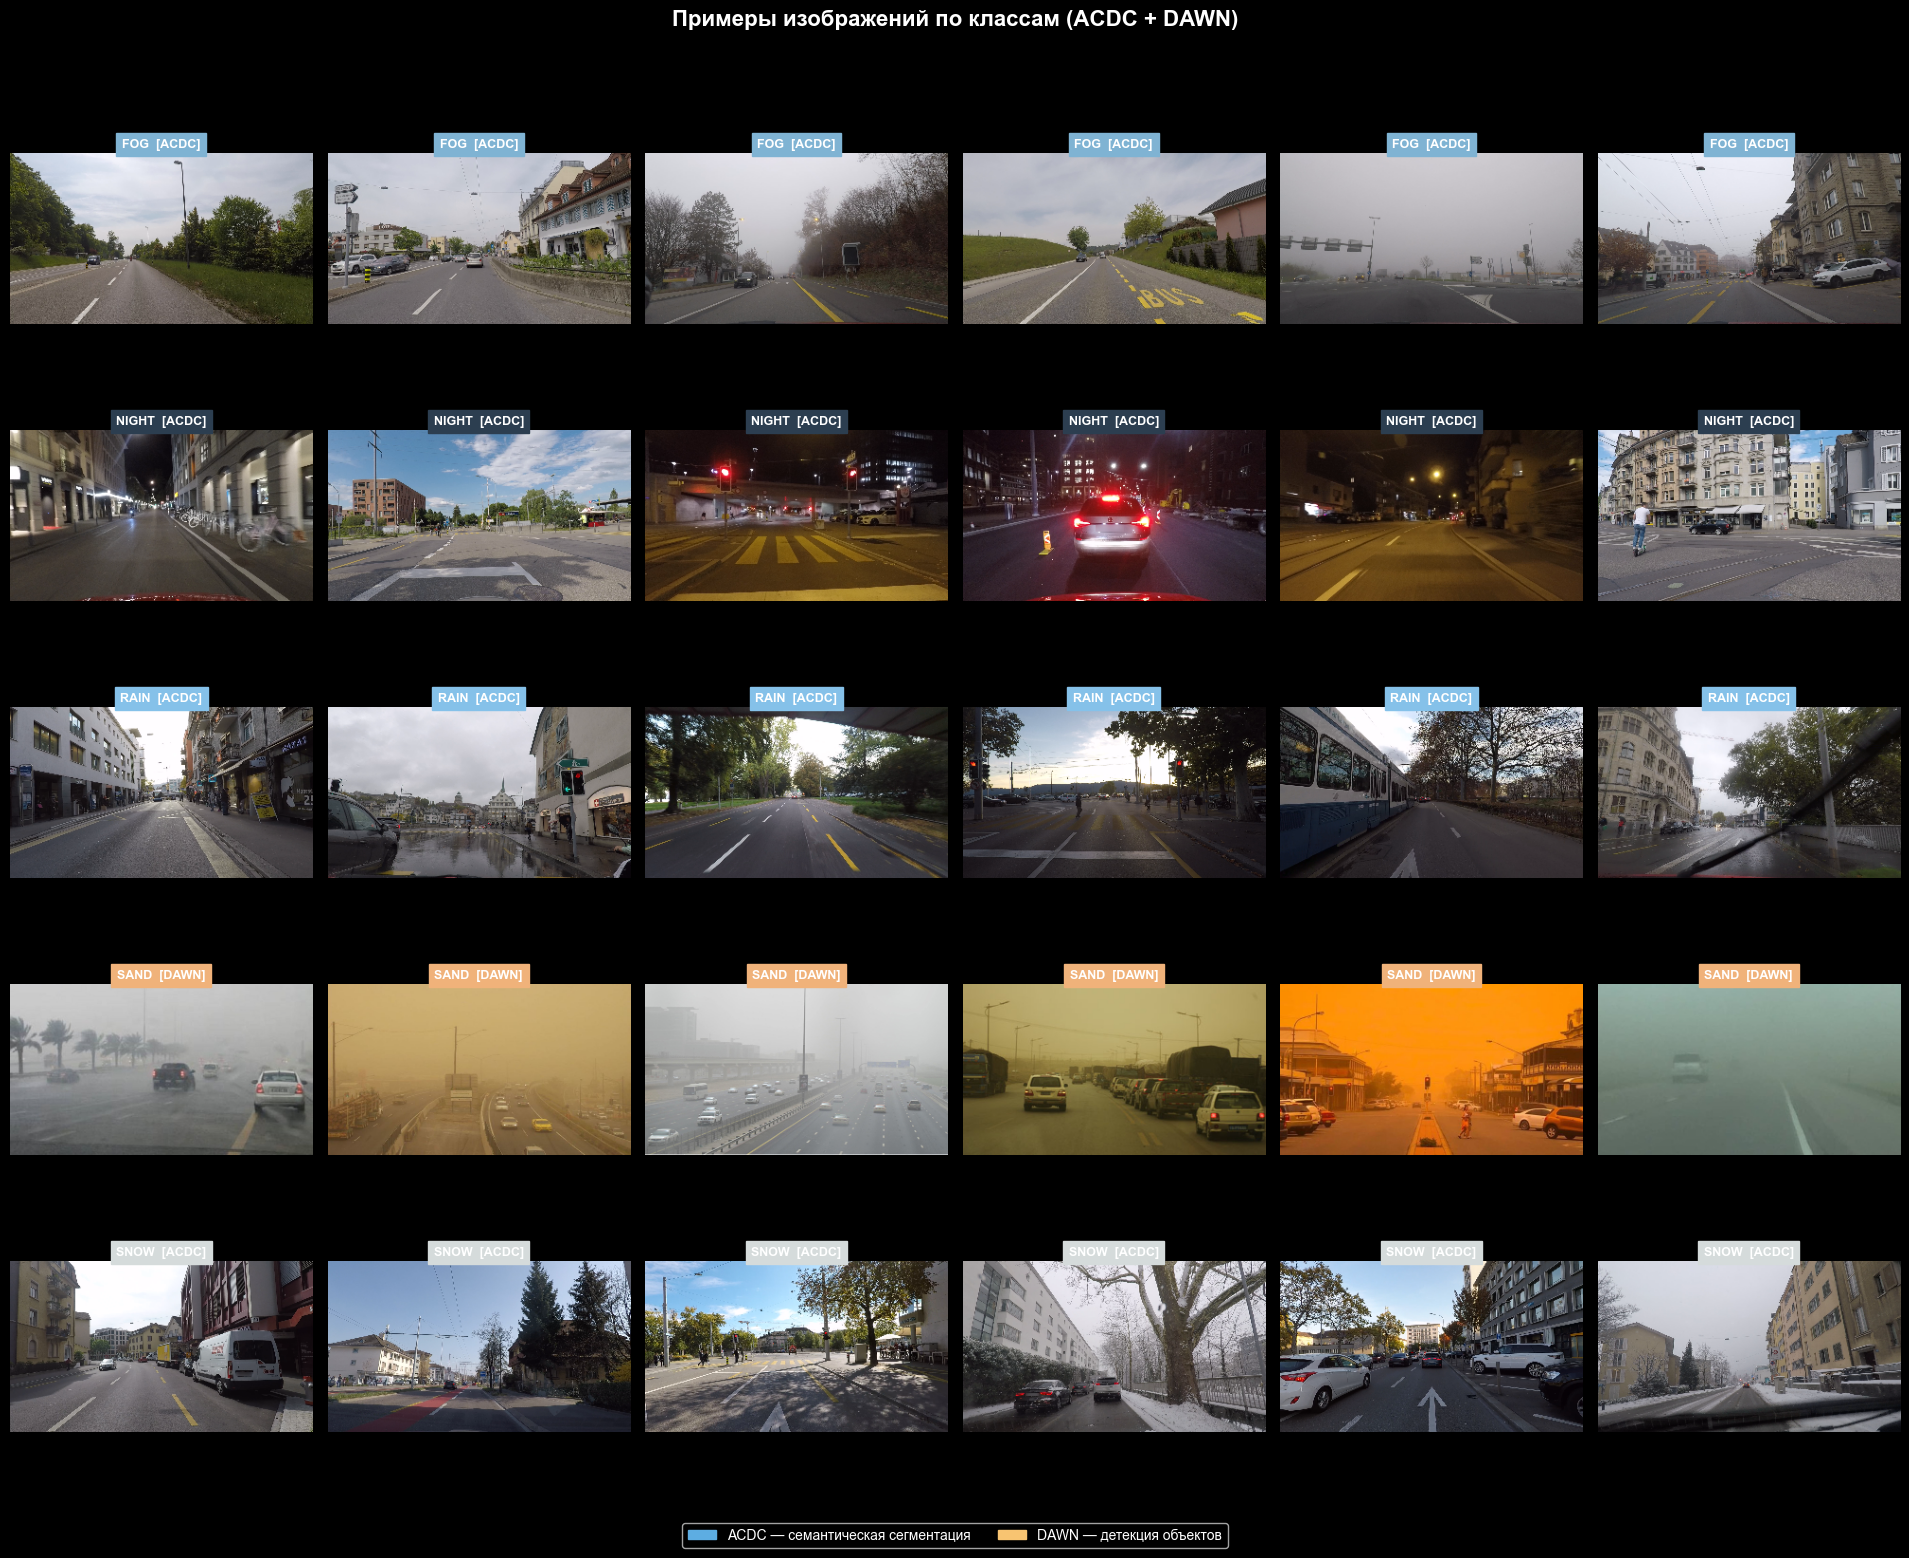

In [9]:
SAMPLES_PER_CLASS = 6
labels_order = sorted(combined_df['label'].unique())
n_classes = len(labels_order)

fig, axes = plt.subplots(
    n_classes, SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 3.2, n_classes * 3)
)
fig.suptitle('Примеры изображений по классам (ACDC + DAWN)', fontsize=16, fontweight='bold', y=1.01)

for row_idx, label in enumerate(labels_order):
    subset = combined_df[combined_df['label'] == label].sample(
        min(SAMPLES_PER_CLASS, len(combined_df[combined_df['label'] == label])),
        random_state=42
    )
    color = LABEL_COLORS.get(label, '#AAAAAA')

    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx, col_idx]
        ax.axis('off')

        if col_idx < len(subset):
            row = subset.iloc[col_idx]
            img = cv2.imread(row['path'])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (320, 180))
                ax.imshow(img)

                # ← Подпись: класс + источник на каждой картинке
                ax.set_title(
                    f"{label.upper()}  [{row['source']}]",
                    fontsize=9,
                    fontweight='bold',
                    color='white',
                    backgroundcolor=color,
                    pad=4
                )

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
                spine.set_visible(True)

        else:
            # Пустая ячейка — заглушка
            ax.set_facecolor('#F0F0F0')
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)

legend_patches = [
    mpatches.Patch(color='#5DADE2', label='ACDC — семантическая сегментация'),
    mpatches.Patch(color='#F8C471', label='DAWN — детекция объектов'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()
